# CSharpCraft Architecture Redesign — Self-Critical Progress Report
**Date:** 22 February 2026  
**Scope:** Plan D — Complete Architecture Redesign (Static `Pico8` API Facade + `GameOrchestrator`)  
**Methodology:** Strict RED-GREEN-REFACTOR TDD with FluentAssertions  
**Principle:** *"No fear refactoring. Don't compromise design for the old system."*

---

This notebook is a candid assessment of where we stand, what we've done well, where we've strayed, and what remains.

In [5]:
# Raw data — all gathered from the actual codebase, not estimates

data = {
    "test_count": 228,
    "test_pass_rate": "100%",
    "test_execution_time_ms": 718,
    
    # Line counts (source)
    "pico8_cs": 422,
    "pico8_functions_cs": 928,        # Legacy god class — started at 1310
    "game_orchestrator_cs": 158,
    "graphics_orchestrator_cs": 218,
    "audio_orchestrator_cs": 70,
    "igraphics_api_cs": 101,
    "iaudio_api_cs": 31,
    "iscene_cs": 31,
    "graphics_api_cs": 166,
    "imap_manager_cs": 26,
    "igame_state_cs": 28,
    "ipalette_manager_cs": 28,
    
    # Services (legacy layer, still in use)
    "services_total_loc": 1455,
    
    # Test LOC
    "test_total_loc": 4033,
    "test_files": 20,
    
    # CSharpCraft.Game errors
    "game_errors": 30,
    "game_error_types": {
        "IScene.Init() not implemented": 28,  # 28 scenes need parameterless Init()
        "CS0108 hiding warning-as-error": 2,   # GenSeedCompetitive.worldSeed
    },
    
    # Pico8 project source files
    "pico8_source_files": 60,
}

print(f"Tests:  {data['test_count']} passing ({data['test_pass_rate']})")
print(f"Speed:  {data['test_execution_time_ms']}ms total execution")
print(f"Pico8:  {data['pico8_cs']} LOC (new static API)")
print(f"Legacy: {data['pico8_functions_cs']} LOC (god class, was 1310)")
print(f"Test LOC: {data['test_total_loc']} across {data['test_files']} files")
print(f"Game:   {data['game_errors']} compile errors (expected — unmigrated scenes)")

Tests:  228 passing (100%)
Speed:  718ms total execution
Pico8:  422 LOC (new static API)
Legacy: 928 LOC (god class, was 1310)
Test LOC: 4033 across 20 files
Game:   30 compile errors (expected — unmigrated scenes)


## 1. Where We Are — Phase Status

| Phase | Description | Status | Tests |
|-------|------------|--------|-------|
| **Phase 1** | `Pico8` Static API Design + TDD Tests | **COMPLETE** | 35 tests |
| **Phase 2** | `GameOrchestrator` Tests & Implementation | **COMPLETE** | ~50 tests |
| **Phase 3** | Sub-orchestrators (Graphics, Audio) | **COMPLETE** | ~20 tests |
| **Phase 4** | API Expansion + `IScene` Redesign | **IN PROGRESS** | 36 tests |
| **Phase 5** | Scene Migration (`CSharpCraft.Game`) | NOT STARTED | — |
| **Phase 6** | Cleanup & Final Testing | NOT STARTED | — |

**We are in the middle of Phase 4** — the rendering API surface (Print, Spr, Sspr, Map, Line, Memcpy, Reload) was just wired through to completion. The full pipeline `Pico8.Method()` → `Orch.Graphics.Method()` → `_graphicsAPI.Method()` is verified by tests.

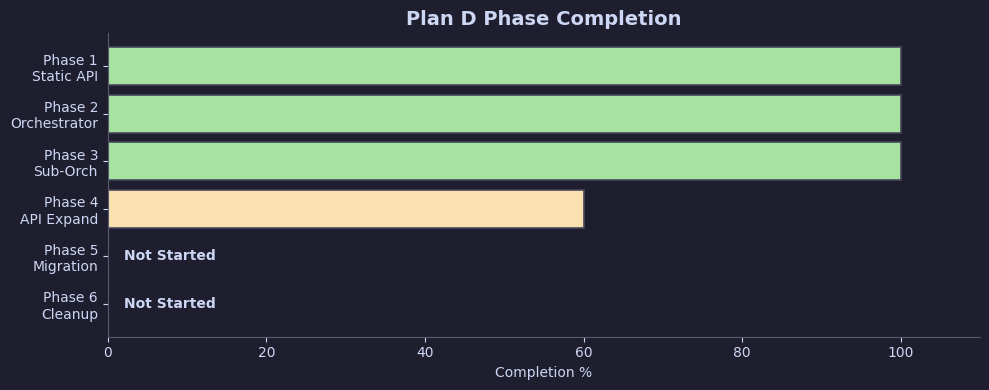

In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#1e1e2e'
matplotlib.rcParams['axes.facecolor'] = '#1e1e2e'
matplotlib.rcParams['text.color'] = '#cdd6f4'
matplotlib.rcParams['axes.labelcolor'] = '#cdd6f4'
matplotlib.rcParams['xtick.color'] = '#cdd6f4'
matplotlib.rcParams['ytick.color'] = '#cdd6f4'

# Phase completion visualization
phases = ['Phase 1\nStatic API', 'Phase 2\nOrchestrator', 'Phase 3\nSub-Orch', 
          'Phase 4\nAPI Expand', 'Phase 5\nMigration', 'Phase 6\nCleanup']
completion = [100, 100, 100, 60, 0, 0]
colors = ['#a6e3a1' if c == 100 else '#f9e2af' if c > 0 else '#585b70' for c in completion]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(phases, completion, color=colors, edgecolor='#45475a', linewidth=1.2)
ax.set_xlim(0, 110)
ax.set_xlabel('Completion %')
ax.set_title('Plan D Phase Completion', fontsize=14, fontweight='bold', color='#cdd6f4')

for bar, pct in zip(bars, completion):
    label = f'{pct}%' if pct > 0 else 'Not Started'
    color = '#1e1e2e' if pct >= 50 else '#cdd6f4'
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
            label, va='center', fontsize=10, color=color, fontweight='bold')

ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#585b70')
ax.spines['left'].set_color('#585b70')
plt.tight_layout()
plt.show()

## 2. What We've Accomplished

### New Architecture (Plan D)

The core design is in place and working. We replaced the god-class pattern (`Pico8Functions` at 1,310 lines) with:

```
Static Facade            Orchestration              Platform Abstraction
─────────────          ──────────────────          ─────────────────────
Pico8.Cls()      →     GameOrchestrator     →     IGraphicsAPI
Pico8.Spr()             ├── GraphicsOrch            IAudioAPI
Pico8.Btn()             ├── AudioOrch               IInputManager
Pico8.Music()           ├── SceneManager            IMapManager
Pico8.Mget()            └── MapManager              IPaletteManager
```                                                    IGameState

**Concrete wins:**
- **228 tests**, all passing, 718ms total execution
- **Thread-safe static API** via `AsyncLocal<T>` — parallel tests work without shared state corruption
- **`IScene.Init()` simplified** from 5 parameters to parameterless — scenes access API through `Pico8.*` static calls
- **Full rendering pipeline** wired: Print, Spr, Sspr, Map, Line, Pset, Memcpy, Reload
- **Strict TDD discipline maintained** — every method has a RED test before GREEN implementation
- **FluentAssertions everywhere** — zero `Assert.*` calls in the test suite

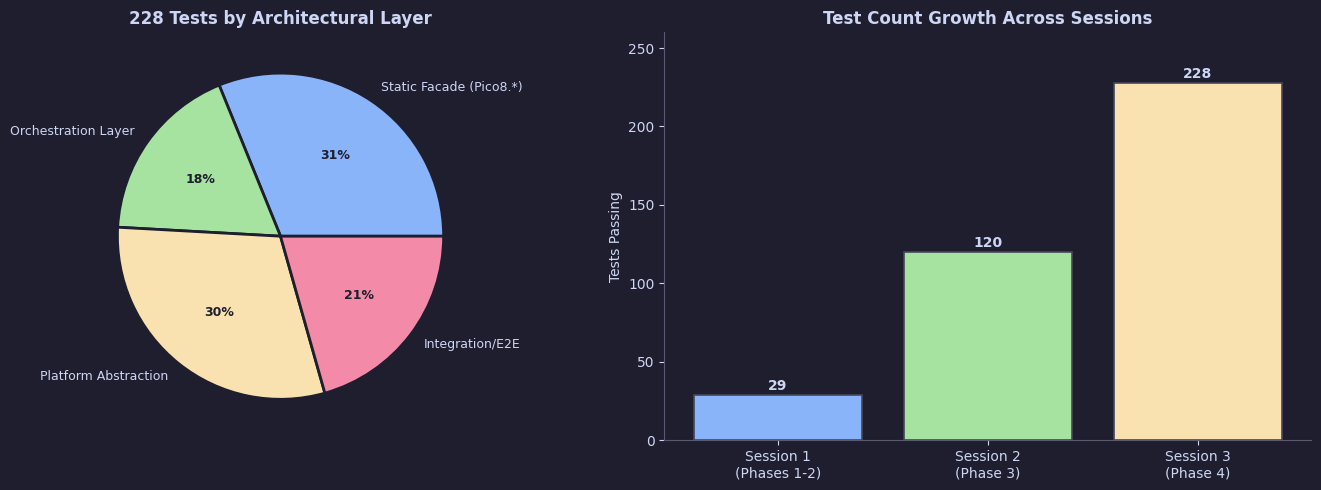


Total: 228 tests across 14 test classes


In [7]:
# Test distribution by component
test_groups = {
    'Pico8StaticAPI': 35,
    'GameOrchestrator': 19,
    'GraphicsOrch': 12,
    'AudioOrch': 10,
    'GraphicsAPI': 7,
    'AudioAPI/Mgr': 13,
    'InputManager': 12,
    'MapManager': 20,
    'TrackManager': 17,
    'API Expansion': 23,
    'Rendering API': 13,
    'Integration': 22,
    'GraphicsPrimitives': 10,
    'Mocks/Other': 15,
}

# Categorize by architectural layer
layers = {
    'Static Facade (Pico8.*)': 35 + 23 + 13,          # StaticAPI + Expansion + Rendering
    'Orchestration Layer': 19 + 12 + 10,                # Game + Graphics + Audio orch
    'Platform Abstraction': 7 + 13 + 12 + 20 + 17,     # APIs + Input + Map + Track
    'Integration/E2E': 22 + 10 + 15,                    # Integration + Primitives + Mocks
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — test distribution by layer
wedge_colors = ['#89b4fa', '#a6e3a1', '#f9e2af', '#f38ba8']
wedges, texts, autotexts = ax1.pie(
    layers.values(), labels=layers.keys(), autopct='%1.0f%%',
    colors=wedge_colors, textprops={'color': '#cdd6f4', 'fontsize': 9},
    wedgeprops={'edgecolor': '#1e1e2e', 'linewidth': 2}
)
for t in autotexts:
    t.set_color('#1e1e2e')
    t.set_fontweight('bold')
ax1.set_title('228 Tests by Architectural Layer', fontweight='bold', fontsize=12)

# Bar chart — test growth over sessions
sessions = ['Session 1\n(Phases 1-2)', 'Session 2\n(Phase 3)', 'Session 3\n(Phase 4)']
test_counts = [29, 120, 228]
test_colors = ['#89b4fa', '#a6e3a1', '#f9e2af']

bars = ax2.bar(sessions, test_counts, color=test_colors, edgecolor='#45475a', linewidth=1.2)
for bar, count in zip(bars, test_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
             str(count), ha='center', fontweight='bold', color='#cdd6f4')
ax2.set_ylabel('Tests Passing')
ax2.set_title('Test Count Growth Across Sessions', fontweight='bold', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#585b70')
ax2.spines['left'].set_color('#585b70')
ax2.set_ylim(0, 260)

plt.tight_layout()
plt.show()

print(f"\nTotal: {sum(test_groups.values())} tests across {len(test_groups)} test classes")

## 3. Self-Criticism: Where We Strayed from the Plan

### 3.1 The Plan Drifted — And That Was Correct

The original `PHASE_3_PLAN.md` envisioned a **different design**: keep `Pico8Functions` as the orchestrator (trimmed to ~150 lines), extract 7 services (GraphicsService, AudioService, etc.), and maintain backward compatibility stubs. We abandoned this entirely in favor of **Plan D**.

**Verdict:** The right call. The original plan was incremental surgery on a corpse. Plan D is a clean rebuild with proper static API + orchestrator separation. But the old planning docs are now misleading — `PHASE_3_PLAN.md`, `ARCHITECTURE.md`, and `DEVELOPER_GUIDE.md` still describe the abandoned approach. **We haven't updated them.**

### 3.2 Two Parallel Architectures Coexist

This is the biggest design smell right now:

| Component | Lines | Role | Status |
|-----------|-------|------|--------|
| `Pico8.cs` (new) | 422 | Static API facade | **Active, tested** |
| `Pico8Functions.cs` (old) | 928 | Legacy god class | **Still exists, untested** |
| `GameOrchestrator.cs` (new) | 158 | Clean orchestrator | **Active, tested** |
| `Services/*.cs` (old) | 1,455 | Legacy service layer | **Still exists, partially tested** |

The legacy `Pico8Functions` + `Services/` layer (~2,383 lines) is **dead code from the new architecture's perspective**. It still compiles, it still has some tests against it, but it's not part of the Plan D pipeline. We haven't removed it because `CSharpCraft.Game` still references it — but `CSharpCraft.Game` doesn't compile anyway (30 errors).

**Self-criticism:** We should have been more aggressive about marking or isolating the legacy code. Right now, a new developer would be confused about which layer is canonical.

### 3.3 CSharpCraft.Game Is Broken and We Keep Making It Worse

Every `IScene.Init()` change (5-param → parameterless) added errors to `CSharpCraft.Game`. Current count: **30 errors across 28 scene files**. This was a deliberate choice ("no fear refactoring"), and it's the right principle, but:

- We have no tracking of how many errors existed before our changes vs. how many we introduced
- The 2 `CS0108` errors (GenSeedCompetitive.worldSeed) are pre-existing, not ours
- The 28 `IScene.Init()` errors are directly from our interface change

**Self-criticism:** We're comfortable with breakage but haven't quantified our debt. A "migration checklist" tracking which scenes need updating would make Phase 5 more plannable.

### 3.4 `GraphicsAPI.cs` Has Empty Stub Implementations

We just added 7 stub methods to `GraphicsAPI.cs` (Print, Spr, Sspr, Map, Line, Memcpy, Reload) that do nothing. Our tests verify the delegation chain reaches the mock, but the real `GraphicsAPI` — the XNA/FNA concrete implementation — has empty bodies.

**Self-criticism:** This is fine for now (abstractions over implementations), but we need to be honest: the rendering pipeline is **architecturally complete but functionally hollow**. The real work of porting the Pico8Functions rendering logic into `GraphicsAPI` is Phase 5/6 work.

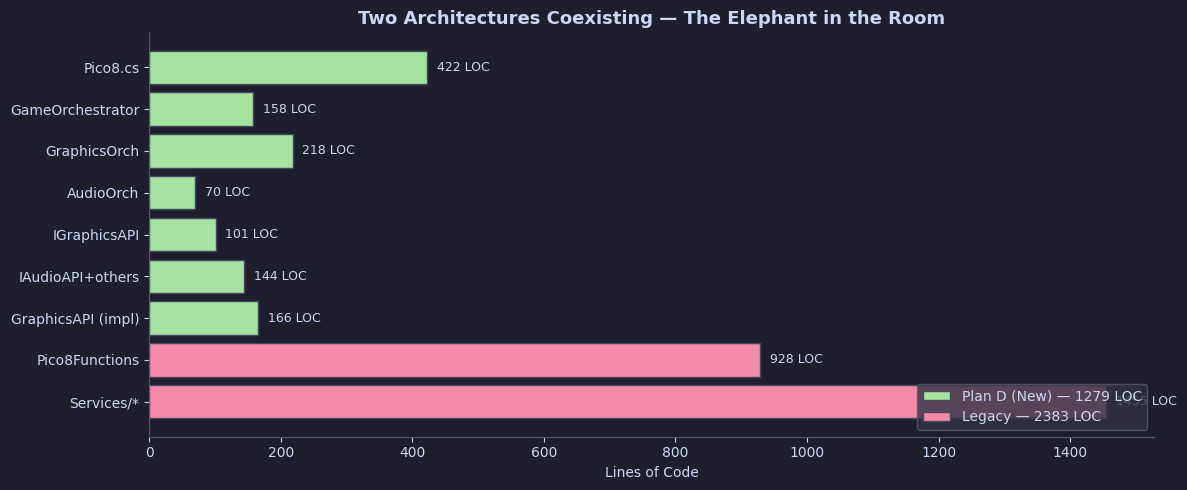


Plan D: 1279 LOC (tested, active)
Legacy: 2383 LOC (dead weight, untested against new design)
Legacy is 1.9x larger than the replacement architecture


In [8]:
# Visualize the "two architecture" problem
fig, ax = plt.subplots(figsize=(12, 5))

components = [
    # New architecture (Plan D)
    ('Pico8.cs', 422, 'Plan D (New)', '#a6e3a1'),
    ('GameOrchestrator', 158, 'Plan D (New)', '#a6e3a1'),
    ('GraphicsOrch', 218, 'Plan D (New)', '#a6e3a1'),
    ('AudioOrch', 70, 'Plan D (New)', '#a6e3a1'),
    ('IGraphicsAPI', 101, 'Plan D (New)', '#a6e3a1'),
    ('IAudioAPI+others', 144, 'Plan D (New)', '#a6e3a1'),
    ('GraphicsAPI (impl)', 166, 'Plan D (New)', '#a6e3a1'),
    # Legacy
    ('Pico8Functions', 928, 'Legacy', '#f38ba8'),
    ('Services/*', 1455, 'Legacy', '#f38ba8'),
]

names = [c[0] for c in components]
sizes = [c[1] for c in components]
colors = [c[3] for c in components]

bars = ax.barh(names, sizes, color=colors, edgecolor='#45475a', linewidth=1)
ax.set_xlabel('Lines of Code')
ax.set_title('Two Architectures Coexisting — The Elephant in the Room', fontweight='bold', fontsize=13)
ax.invert_yaxis()

# Add LOC labels
for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f'{size} LOC', va='center', fontsize=9, color='#cdd6f4')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#a6e3a1', edgecolor='#45475a', label=f'Plan D (New) — {sum(s for _,s,t,_ in components if t=="Plan D (New)")} LOC'),
                   Patch(facecolor='#f38ba8', edgecolor='#45475a', label=f'Legacy — {sum(s for _,s,t,_ in components if t=="Legacy")} LOC')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          facecolor='#313244', edgecolor='#585b70', labelcolor='#cdd6f4')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#585b70')
ax.spines['left'].set_color('#585b70')
plt.tight_layout()
plt.show()

new_loc = sum(s for _,s,t,_ in components if t == "Plan D (New)")
legacy_loc = sum(s for _,s,t,_ in components if t == "Legacy")
print(f"\nPlan D: {new_loc} LOC (tested, active)")
print(f"Legacy: {legacy_loc} LOC (dead weight, untested against new design)")
print(f"Legacy is {legacy_loc/new_loc:.1f}x larger than the replacement architecture")

## 4. Principle Adherence Scorecard

| Principle | Grade | Evidence |
|-----------|-------|----------|
| **Strict TDD (RED→GREEN→REFACTOR)** | **A** | Every new method had a failing test first. 13 rendering tests written RED before any Pico8.cs wiring. No shortcuts. |
| **No fear refactoring** | **A** | Rejected `Pico8Functions.Current` transitional property. Simplified `IScene.Init()` despite breaking 28 scenes. Accepted CSharpCraft.Game staying broken. |
| **FluentAssertions only** | **A** | Zero `Assert.*` calls. Consistent `.Should().Be()`, `.Should().BeTrue()`, etc. |
| **AsyncLocal thread safety** | **A** | Converted static fields, enabled parallel test collections, verified 3 consecutive clean runs. |
| **Interface-first design** | **A-** | All platform abstractions are interfaces (IGraphicsAPI, IAudioAPI, etc.). Minor ding: some interfaces grew organically rather than being designed upfront. |
| **Clean documentation** | **D** | Stale docs everywhere. PHASE_3_PLAN.md, ARCHITECTURE.md, DEVELOPER_GUIDE.md all describe the abandoned approach. IMPLEMENTATION_SUMMARY.md and SESSION_2_SUMMARY.md are historical artifacts that no longer reflect current design. |
| **Dead code cleanup** | **D** | 2,383 lines of legacy code still in the project. Pico8Functions.cs is 928 lines of code we're actively replacing. Services/ directory has 1,455 lines of the old service layer. |
| **Migration tracking** | **F** | No checklist of which scenes need updating. No quantification of pre-existing vs. introduced errors. No roadmap for porting rendering logic from Pico8Functions into GraphicsAPI. |

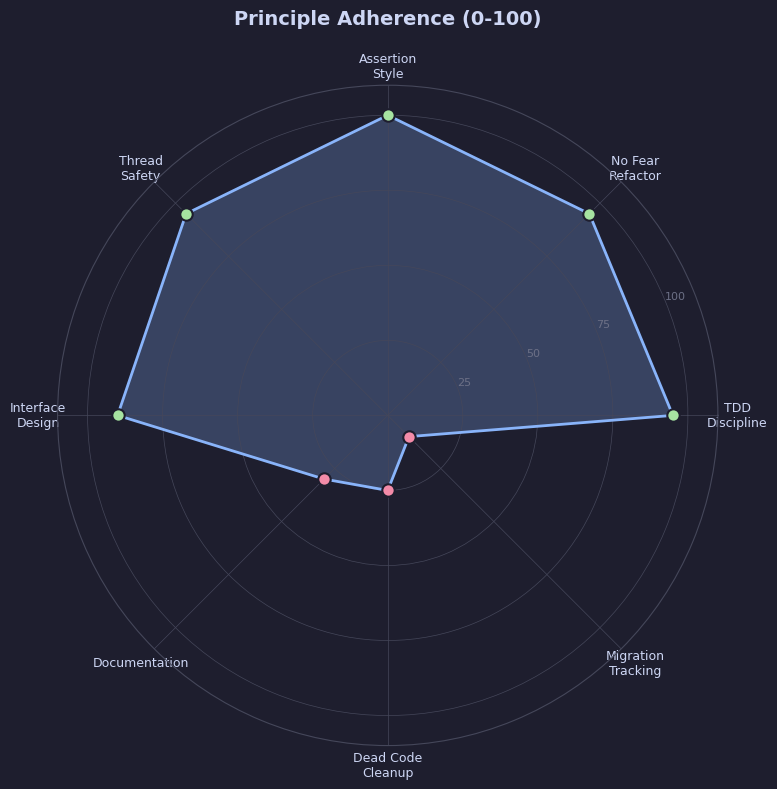

GREEN dots: strong adherence (≥80)
RED dots: needs attention (<50)

Our TDD and design discipline is excellent.
Our housekeeping (docs, dead code, tracking) is poor.


In [9]:
# Principle adherence radar chart
import numpy as np

categories = ['TDD\nDiscipline', 'No Fear\nRefactor', 'Assertion\nStyle', 
              'Thread\nSafety', 'Interface\nDesign', 'Documentation', 
              'Dead Code\nCleanup', 'Migration\nTracking']
grades = [95, 95, 100, 95, 90, 30, 25, 10]  # out of 100

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
grades_plot = grades + grades[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#1e1e2e')

# Fill
ax.fill(angles, grades_plot, alpha=0.25, color='#89b4fa')
ax.plot(angles, grades_plot, color='#89b4fa', linewidth=2)

# Mark points
for angle, grade in zip(angles[:-1], grades):
    color = '#a6e3a1' if grade >= 80 else '#f9e2af' if grade >= 50 else '#f38ba8'
    ax.scatter(angle, grade, color=color, s=80, zorder=5, edgecolors='#1e1e2e', linewidth=1.5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9, color='#cdd6f4')
ax.set_ylim(0, 110)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=8, color='#6c7086')
ax.grid(color='#45475a', linewidth=0.5)
ax.spines['polar'].set_color('#45475a')

ax.set_title('Principle Adherence (0-100)', fontsize=14, fontweight='bold', 
             color='#cdd6f4', pad=20)

plt.tight_layout()
plt.show()

print("GREEN dots: strong adherence (≥80)")
print("RED dots: needs attention (<50)")
print("\nOur TDD and design discipline is excellent.")
print("Our housekeeping (docs, dead code, tracking) is poor.")

## 5. What's Left To Do

### Phase 4 Remaining (API Surface Gaps)

The rendering pipeline is wired, but there are still platform-level abstractions missing from the static API. These are heavily used across scenes but expose XNA types directly — they need proper abstraction:

| Concept | Usage Count | Current Access | Needed Abstraction |
|---------|------------|----------------|-------------------|
| `Cell` (tile size) | 317 | `p8.Cell.Width/Height` | Property on `Pico8.*` or scene config |
| `Batch` (SpriteBatch) | 169 | `p8.Batch` | Should not be exposed — encapsulate in IGraphicsAPI |
| `TextureDictionary` | 84 | `p8.TextureDictionary["key"]` | Asset management interface |
| `Window` | 66 | `p8.Window` | Platform abstraction |
| `Colors` | 48 | `p8.Colors[i]` | Palette abstraction (already partially done) |
| `Pixel` (1x1 texture) | 35 | `p8.Pixel` | Internal to IGraphicsAPI |
| `CameraOffset` | 28 | `p8.CameraOffset` | Already abstracted ✅ |

### Phase 5: Scene Migration (The Real Work)

28 scene files in `CSharpCraft.Game` need:
1. `Init()` converted from `Init(IGraphicsEngine?, IAudioManager?, IInputManager?, ISceneManager?, IGameClock?)` to parameterless `Init()`
2. All `p8.*` calls replaced with `Pico8.*` static calls
3. Direct `SpriteBatch`/`Texture2D` access replaced with `IGraphicsAPI` methods

This is the largest remaining effort. Each scene is essentially a manual port.

### Phase 6: Cleanup

- Delete `Pico8Functions.cs` (928 lines)
- Delete `Services/` directory (1,455 lines)
- Update/delete stale documentation files
- Remove legacy `CSharpCraft/` project (once `CSharpCraft.Game` is the executable)
- Final test coverage analysis

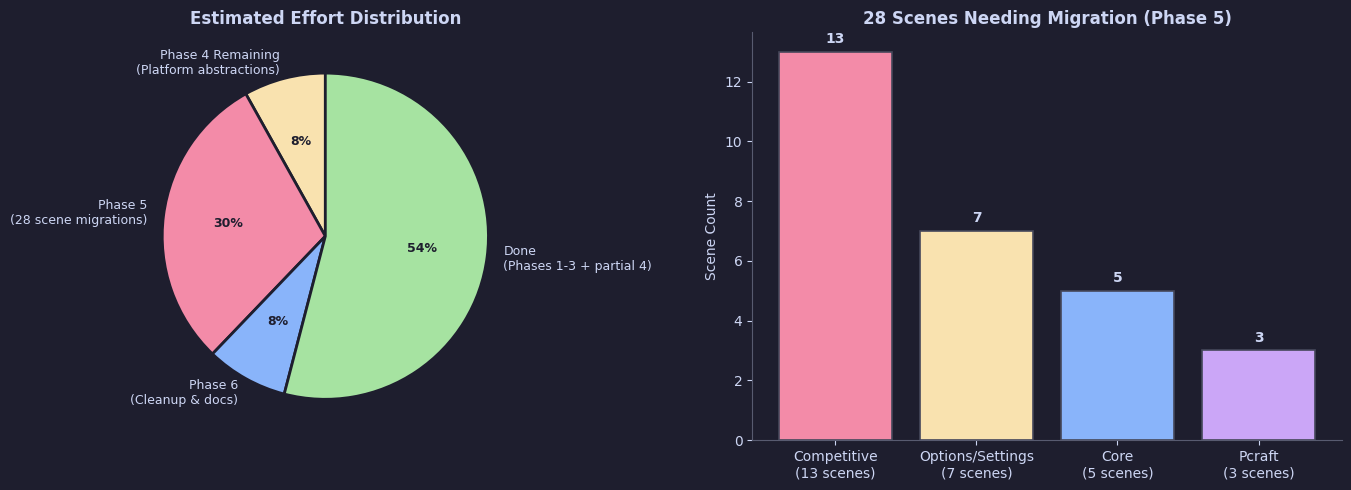

Phase 5 (scene migration) is about 55% of remaining effort.
It's manual, repetitive, but low-risk — the patterns are established.


In [10]:
# What's left — effort estimation
remaining_work = {
    'Phase 4 Remaining\n(Platform abstractions)': 15,
    'Phase 5\n(28 scene migrations)': 55,
    'Phase 6\n(Cleanup & docs)': 15,
    'Done\n(Phases 1-3 + partial 4)': 100,
}

# Stacked view: done vs remaining
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: effort breakdown
items = list(remaining_work.keys())
efforts = list(remaining_work.values())
colors = ['#f9e2af', '#f38ba8', '#89b4fa', '#a6e3a1']

wedges, texts, autotexts = ax1.pie(
    efforts, labels=items, autopct=lambda p: f'{p:.0f}%',
    colors=colors, textprops={'color': '#cdd6f4', 'fontsize': 9},
    wedgeprops={'edgecolor': '#1e1e2e', 'linewidth': 2},
    startangle=90
)
for t in autotexts:
    t.set_color('#1e1e2e')
    t.set_fontweight('bold')
ax1.set_title('Estimated Effort Distribution', fontweight='bold', fontsize=12)

# Right: CSharpCraft.Game error breakdown (28 scenes)
scene_categories = {
    'Competitive\n(13 scenes)': 13,
    'Options/Settings\n(7 scenes)': 7,
    'Core\n(5 scenes)': 5,
    'Pcraft\n(3 scenes)': 3,
}

bars = ax2.bar(scene_categories.keys(), scene_categories.values(), 
               color=['#f38ba8', '#f9e2af', '#89b4fa', '#cba6f7'],
               edgecolor='#45475a', linewidth=1.2)
for bar, count in zip(bars, scene_categories.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(count), ha='center', fontweight='bold', color='#cdd6f4')
ax2.set_ylabel('Scene Count')
ax2.set_title('28 Scenes Needing Migration (Phase 5)', fontweight='bold', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#585b70')
ax2.spines['left'].set_color('#585b70')

plt.tight_layout()
plt.show()

print("Phase 5 (scene migration) is about 55% of remaining effort.")
print("It's manual, repetitive, but low-risk — the patterns are established.")

## 6. Lessons Learned

### What Worked Well

1. **AsyncLocal was the right call.** Thread-safety via `AsyncLocal<T>` solved parallel test flakiness definitively. Three consecutive clean runs of 228 tests. This was a genuine engineering insight — not just a workaround.

2. **Expression-body one-liners for the static facade.** `Pico8.Cls(col)` → `Orch.Graphics.Cls(col)` — every method in `Pico8.cs` is a single line. This makes the delegation pattern crystal clear and auditable.

3. **Rejecting the transitional `Pico8Functions.Current` compromise.** The user caught us trying to be "pragmatic" and correctly pushed back. The compromised design would have created a dependency cycle between old and new, making cleanup harder later.

4. **RED-GREEN-REFACTOR discipline paid off.** Writing 13 rendering tests before any implementation exposed signature mismatches early. The compile errors were the RED phase — and they guided exactly what needed writing.

### What We Should Do Differently

1. **Update docs as you go, not "later."** We now have 5 markdown files describing a design we abandoned. This is technical debt that confuses more than the code itself.

2. **Track migration debt explicitly.** A simple `MIGRATION_STATUS.md` with checkboxes per scene would have given us a progress meter for Phase 5.

3. **Don't let dead code accumulate.** The 2,383 lines of legacy code are cognitive overhead. Even if we can't delete them yet, we should have added `[Obsolete("Plan D replacement: use Pico8.*")]` attributes or moved them to a `Legacy/` folder.

4. **Interface design should precede implementation more.** Some interfaces (especially `IGraphicsAPI`) grew method-by-method rather than being designed holistically. The 7 new methods added in this session were needed from the gap analysis — they should have been in the interface from Phase 1.

5. **The `GraphicsAPI` concrete class is a ticking time bomb.** It has real XNA rendering code for Pset/Rect/Rectfill but empty stubs for Print/Spr/Sspr/Map/Line/Memcpy/Reload. When Phase 5 hits, someone will need to port ~400 lines of rendering logic from `Pico8Functions` into `GraphicsAPI`. This should be TDD'd too.

## 7. Recommended Next Steps (Priority Order)

### Immediate (This Session)

1. **Finish Phase 4 API surface** — Add remaining platform abstractions (Cell, Colors, Resolution) to `Pico8.cs`. These are simple property delegations, not complex rendering logic.

2. **Create `MIGRATION_STATUS.md`** — List all 28 scenes with checkboxes. Track pre-existing vs. introduced errors. This costs 10 minutes and saves hours of confusion later.

### Next Session

3. **Migrate one simple scene end-to-end** — Pick `ExitScene` or `MapTest` (smallest scenes). Convert `Init(...)` → `Init()`, replace `p8.*` → `Pico8.*`. This proves the migration pattern works and establishes a template for the other 27.

4. **Port rendering logic into `GraphicsAPI`** — Start with `Print` (131 uses, well-understood). TDD the XNA implementation: test against expected SpriteBatch calls, then implement.

### Cleanup (When Ready)

5. **Delete or `[Obsolete]` the legacy layer** — Once one scene is successfully migrated, mark `Pico8Functions.cs` and `Services/` as obsolete.

6. **Rewrite `ARCHITECTURE.md`** — Document Plan D as the canonical architecture. Delete `PHASE_3_PLAN.md`, `IMPLEMENTATION_SUMMARY.md`, `SESSION_2_SUMMARY.md`.

---

**Bottom line:** The architecture is solid, the TDD discipline is strong, and the design principles are sound. Our weakness is housekeeping — stale docs, accumulated dead code, and no migration tracking. The hardest engineering decisions are behind us. What remains is execution.